# Charter-to-Corpus Matching

Two-stage approach:
1. **Fast retrieval** — character n-gram TF-IDF cosine similarity to shortlist top-K candidates per transcription
2. **Precise re-ranking** — `rapidfuzz` normalized Levenshtein similarity on the shortlisted pairs

**Inputs:**
- `transcriptions/` — VLM-generated `.txt` files (one per charter image)
- `cd-admin-txt/` — Converted Corpus Gysseling `.txt` files
- `mystery-metadata.xlsx` — Metadata spreadsheet to annotate with matches
- `handengroepen_gysseling.xlsx` — Hand-group / individual-hand assignments per charter

**Output:**
- `metadata-matched.xlsx` — metadata annotated with `match`, `match_score`, `gysseling_nr`, the `hand_group`, and the individual `hand` code

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from rapidfuzz.distance import Levenshtein
from tqdm.auto import tqdm
import re

## 1. Configuration

In [10]:
TRANSCRIPTIONS_DIR = Path('transcriptions')       # VLM output
CORPUS_DIR = Path('cd-admin-txt')                  # converted Gysseling corpus
METADATA_FILE = Path('metadata.xlsx')
OUTPUT_FILE = Path('metadata-matched.xlsx')

# Stage 1: how many TF-IDF candidates to shortlist per transcription
TOP_K = 20

# Stage 2: minimum normalized Levenshtein similarity to accept a match
MIN_THRESHOLD = 0.40

## 2. Load texts

In [3]:
def load_texts(directory: Path) -> dict[str, str]:
    """Load all .txt files from a directory into a {filename: text} dict."""
    texts = {}
    for f in sorted(directory.glob('*.txt')):
        try:
            text = f.read_text(encoding='utf-8')
        except UnicodeDecodeError:
            text = f.read_text(encoding='latin-1')
        texts[f.name] = text
    return texts

transcriptions = load_texts(TRANSCRIPTIONS_DIR)
corpus = load_texts(CORPUS_DIR)

print(f'Transcriptions: {len(transcriptions)} files')
print(f'Corpus texts:   {len(corpus)} files')

Transcriptions: 1408 files
Corpus texts:   2228 files


## 3. Preprocessing

Lowercase, strip non-alphanumeric, collapse whitespace.

In [4]:
def normalize(text: str) -> str:
    text = text.lower()
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

trans_names = list(transcriptions.keys())
corpus_names = list(corpus.keys())

trans_normed = [normalize(transcriptions[n]) for n in trans_names]
corpus_normed = [normalize(corpus[n]) for n in corpus_names]

print(f'Example transcription (first 200 chars):\n  {trans_normed[0][:200]}')
print(f'\nExample corpus text (first 200 chars):\n  {corpus_normed[0][:200]}')

Example transcription (first 200 chars):
  jan de neue jacob matin henri van iugstane borgherlermand jan velem heyer de goede trugghe de leuen ende alard yalme vro zone scepennen ververdden hier alsamen ic dese letteren zullen zien of horen le

Example corpus text (first 200 chars):
  hand a reinerus filius arnulfi bake quem symon bake habet in aduocacia inuadiauit terram ecgart que iacet in uilla sancti bauonis pro xxx marc mansura prope terram pro ix firtonibus xxv d pro ledo bal


## 4. Stage 1: TF-IDF candidate retrieval

Character n-grams (3–5) are robust to HTR spelling variation. We retrieve the top-K candidates per transcription.

In [5]:
all_texts = trans_normed + corpus_normed
n_trans = len(trans_normed)

vec = TfidfVectorizer(analyzer='char_wb', ngram_range=(3, 5),
                       min_df=1, max_df=0.95, sublinear_tf=True)
tfidf = vec.fit_transform(all_texts)

sim = cosine_similarity(tfidf[:n_trans], tfidf[n_trans:])

# For each transcription, get top-K corpus indices
candidates = []
for i in range(n_trans):
    top_idx = np.argsort(sim[i])[::-1][:TOP_K]
    candidates.append(top_idx)

print(f'Similarity matrix: {sim.shape}')
print(f'Shortlisted {TOP_K} candidates per transcription')

Similarity matrix: (1408, 2228)
Shortlisted 20 candidates per transcription


## 5. Stage 2: Levenshtein re-ranking

For each transcription, compute normalized Levenshtein similarity against its top-K candidates. This is a proper character-level alignment — much more precise than n-gram overlap, but feasible because we only run it on ~20 pairs per transcription instead of ~1000.

In [6]:
results = []

for i, tname in enumerate(tqdm(trans_names, desc='Re-ranking')):
    t_text = trans_normed[i]
    
    best_score = -1
    best_corpus = None
    second_score = -1
    second_corpus = None
    tfidf_score_of_best = 0
    
    for ci in candidates[i]:
        c_text = corpus_normed[ci]
        lev_sim = Levenshtein.normalized_similarity(t_text, c_text)
        
        if lev_sim > best_score:
            second_score = best_score
            second_corpus = best_corpus
            best_score = lev_sim
            best_corpus = corpus_names[ci]
            tfidf_score_of_best = sim[i, ci]
        elif lev_sim > second_score:
            second_score = lev_sim
            second_corpus = corpus_names[ci]
    
    results.append({
        'transcription': tname,
        'match': best_corpus if best_score >= MIN_THRESHOLD else None,
        'match_score': round(best_score, 4),
        'tfidf_score': round(tfidf_score_of_best, 4),
        'runner_up': second_corpus,
        'runner_up_score': round(second_score, 4),
        'margin': round(best_score - second_score, 4),
    })

results_df = pd.DataFrame(results)
print(f'\nMatches above threshold ({MIN_THRESHOLD}): '
      f'{results_df["match"].notna().sum()} / {len(results_df)}')
results_df.sort_values('match_score', ascending=False).head(20)

Re-ranking:   0%|          | 0/1408 [00:00<?, ?it/s]


Matches above threshold (0.4): 827 / 1408


,transcription,match,match_score,tfidf_score,runner_up,runner_up_score,margin
1171,788o.txt,1580.txt,0.8969,0.6266,1579.txt,0.4583,0.4386
375,1339o.txt,1733.txt,0.8896,0.4971,0234.txt,0.3553,0.5344
1172,789o.txt,1579.txt,0.8883,0.4886,1525.txt,0.4754,0.4129
297,1269o.txt,1522.txt,0.8704,0.5552,1693bA.txt,0.3756,0.4948
670,336o.txt,0340.txt,0.8660,0.4214,0341.txt,0.4186,0.4474
285,1258o.txt,1613.txt,0.8514,0.4306,1622.txt,0.7445,0.1069
634,303o.txt,0336.txt,0.8505,0.4258,0368a.txt,0.4200,0.4306
739,399o.txt,0514.txt,0.8446,0.3290,0487.txt,0.4514,0.3932
91,1083o.txt,1429.txt,0.8348,0.5392,1760.txt,0.3618,0.4730
433,1391o.txt,0918A.txt,0.8339,0.3473,0918B.txt,0.7523,0.0816


## 6. Diagnostics

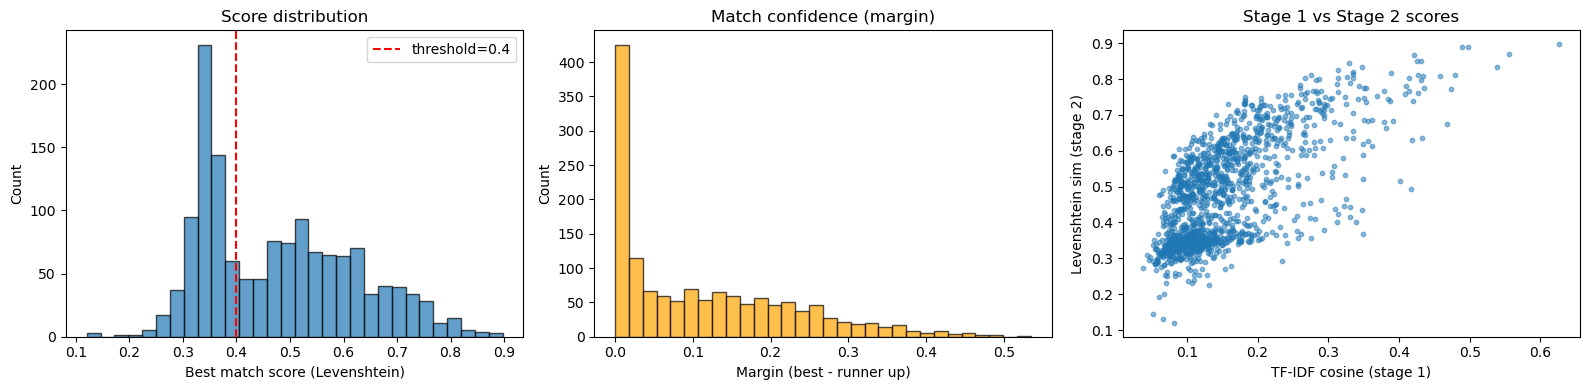

In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(results_df['match_score'], bins=30, edgecolor='black', alpha=0.7)
axes[0].axvline(MIN_THRESHOLD, color='red', linestyle='--', label=f'threshold={MIN_THRESHOLD}')
axes[0].set_xlabel('Best match score (Levenshtein)')
axes[0].set_ylabel('Count')
axes[0].set_title('Score distribution')
axes[0].legend()

axes[1].hist(results_df['margin'], bins=30, edgecolor='black', alpha=0.7, color='orange')
axes[1].set_xlabel('Margin (best - runner up)')
axes[1].set_ylabel('Count')
axes[1].set_title('Match confidence (margin)')

axes[2].scatter(results_df['tfidf_score'], results_df['match_score'], alpha=0.5, s=10)
axes[2].set_xlabel('TF-IDF cosine (stage 1)')
axes[2].set_ylabel('Levenshtein sim (stage 2)')
axes[2].set_title('Stage 1 vs Stage 2 scores')

plt.tight_layout()
plt.show()

## 7. Spot-check matches

In [8]:
def show_match(row, max_chars=500):
    tname = row['transcription']
    cname = row['match']
    if cname is None:
        print(f'--- {tname}: NO MATCH (score={row["match_score"]}) ---\n')
        return
    print(f'--- {tname} -> {cname} (lev={row["match_score"]}, tfidf={row["tfidf_score"]}, margin={row["margin"]}) ---')
    print(f'  TRANSCRIPTION: {transcriptions[tname][:max_chars]}')
    print(f'  CORPUS:        {corpus[cname][:max_chars]}')
    print()

print('=== TOP 5 MATCHES ===')
for _, row in results_df.nlargest(5, 'match_score').iterrows():
    show_match(row)

print('=== BOTTOM 5 MATCHES ===')
for _, row in results_df.nsmallest(5, 'match_score').iterrows():
    show_match(row)

=== TOP 5 MATCHES ===
--- 788o.txt -> 1580.txt (lev=0.8969, tfidf=0.6266, margin=0.4386) ---
  TRANSCRIPTION: Wie proofst Ende capitle van Sente marien in brugge Doen te wetene allen den gonen die
deze letteren zelen zien Ende horen lezen Dat wie quite hebben gheleiden ende stelden qui
te eeuwelike als recht dat wie alden of mochten hebben In dat manieren zoot was am
vierendeel van neghen ymeren ende zeventieneneghentygh roeden lands Ende van ne
ghennentselghen renten thaers Bede land ende rente ligghende in zullwerkere Ende
sloth ant vierendeel van vijfue ymeren ende vere linen lands ligghende in sente
  CORPUS:        zuenkerke
Wie proofst Ende capitle van sente marien in brugghe Doen te
wetene allen den gonen die deze lettren zelen zien Ende horen lezen
Dat wie quite hebben ghescolden ende scelden quite Eewelike alt recht
dat wie adden of mochten hebben jn wat manieren zoot was ant
vierendeel van neghen ymeten ende zevenendeneghentich roeden lands
Ende van neghentienscelghen renten 

## 8. Write results to metadata spreadsheet

In [11]:
meta = pd.read_excel(METADATA_FILE)

match_lookup = {}
for _, row in results_df.iterrows():
    stem = Path(row['transcription']).stem
    match_lookup[stem] = {
        'match': row['match'],
        'match_score': row['match_score'],
    }

def get_match(bestandsnaam):
    if pd.isna(bestandsnaam):
        return None, None
    stem = Path(str(bestandsnaam)).stem
    info = match_lookup.get(stem)
    if info:
        return info['match'], info['match_score']
    return None, None

meta['match'], meta['match_score'] = zip(*meta['bestandsnaam'].map(get_match))

matched = meta['match'].notna().sum()
total = len(meta)
print(f'Matched: {matched}/{total} rows ({matched/total*100:.1f}%)')
meta[meta['match'].notna()][['bestandsnaam', 'match', 'match_score']].head(20)

Matched: 827/2816 rows (29.4%)


,bestandsnaam,match,match_score
2,2o.jpg,0065AA.txt,0.7236
5,3o.jpg,0065A.txt,0.6902
6,4o.jpg,0064.txt,0.6129
8,5o.jpg,0070.txt,0.6338
10,6o.jpg,0074.txt,0.6297
15,8o.jpg,0077.txt,0.6215
17,9o.jpg,0081.txt,0.5166
19,10o.jpg,0050.txt,0.4373
23,12o.jpg,0048.txt,0.5166
24,13o.jpg,0039.txt,0.5129


In [12]:
meta.to_excel(OUTPUT_FILE, index=False)
print(f'Saved to {OUTPUT_FILE}')

Saved to metadata-matched.xlsx


## 9. Threshold sweep

In [13]:
for t in [0.20, 0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.70]:
    n = (results_df['match_score'] >= t).sum()
    print(f'  threshold={t:.2f} -> {n:4d} matches ({n/len(results_df)*100:.1f}%)')

  threshold=0.20 -> 1404 matches (99.7%)
  threshold=0.30 -> 1350 matches (95.9%)
  threshold=0.35 -> 1050 matches (74.6%)
  threshold=0.40 ->  827 matches (58.7%)
  threshold=0.45 ->  733 matches (52.1%)
  threshold=0.50 ->  603 matches (42.8%)
  threshold=0.55 ->  440 matches (31.2%)
  threshold=0.60 ->  313 matches (22.2%)
  threshold=0.70 ->  117 matches (8.3%)


## 10. Add hand groups and individual hands from Gysseling

Load the assignments from `handengroepen_gysseling.xlsx`, map them to each
transcription via its corpus match, and add to the photo metadata:

- `hand_group` — the main hand group (`Type == 'groep'`), as before
- `hand` — the number/code of the **individual hand** for the charter

The individual-hand column is auto-detected; if the wrong column is picked,
set `HAND_COL` explicitly in the cell below.

In [15]:
HANDS_FILE = Path('handengroepen_gysseling.xlsx')

HAND_COL = "Groep"

# Load the full per-charter sheet
hands_full = pd.read_excel(HANDS_FILE, sheet_name='Per oorkonde')
hands_full.columns = [str(c).strip() for c in hands_full.columns]
print(f'"Per oorkonde" columns: {list(hands_full.columns)}')
print(f'Type values: {hands_full["Type"].value_counts().to_dict()}')

GYS_COL = 'Oorkonde (Gysseling-nr.)'
hands_full['gysseling_nr'] = hands_full[GYS_COL].astype(str).str.strip()

# --- Hand GROUP lookup (main groups only, not tussengroepen) ---
groups = hands_full[hands_full['Type'] == 'groep'].copy()
groups['hand_group'] = groups['Groep'].astype(str).str.strip()
group_lookup = dict(zip(groups['gysseling_nr'], groups['hand_group']))
print(f'\nLoaded {len(group_lookup)} charter -> hand group mappings')

if HAND_COL is not None:
    print(f'Using individual-hand column: "{HAND_COL}"')
    h = hands_full[['gysseling_nr', HAND_COL]].copy()
    h[HAND_COL] = h[HAND_COL].astype(str).str.strip()
    # keep first non-empty hand code per charter
    h = h[h[HAND_COL].notna() & (h[HAND_COL] != '') & (h[HAND_COL].str.lower() != 'nan')]
    h = h.drop_duplicates(subset='gysseling_nr', keep='first')
    hand_lookup = dict(zip(h['gysseling_nr'], h[HAND_COL]))
    print(f'Loaded {len(hand_lookup)} charter -> individual hand mappings')
else:
    hand_lookup = {}
    print('WARNING: could not auto-detect an individual-hand column.')
    print('         Set HAND_COL above to the correct column name; '
          '"hand" will be empty until then.')

"Per oorkonde" columns: ['Oorkonde (Gysseling-nr.)', 'Groep', 'Type']
Type values: {'groep': 1147, 'tussengroep': 237}

Loaded 1140 charter -> hand group mappings
Using individual-hand column: "Groep"
Loaded 1377 charter -> individual hand mappings


In [16]:
def corpus_filename_to_gysseling_nr(corpus_fname):
    """Convert corpus filename like '0027.txt' -> '27', '1056a.txt' -> '1056a'."""
    if corpus_fname is None or pd.isna(corpus_fname):
        return None
    stem = Path(str(corpus_fname)).stem  # '0027'
    # Strip leading zeros but keep letter suffixes: '0027' -> '27', '0001' -> '1'
    stripped = stem.lstrip('0') or '0'
    return stripped

# Add gysseling_nr, hand_group, and the individual hand to results_df
results_df['gysseling_nr'] = results_df['match'].map(corpus_filename_to_gysseling_nr)
results_df['hand_group'] = results_df['gysseling_nr'].map(group_lookup)
results_df['hand'] = results_df['gysseling_nr'].map(hand_lookup)

matched_total = results_df['match'].notna().sum()
matched_groups = results_df['hand_group'].notna().sum()
matched_hands = results_df['hand'].notna().sum()
print(f'Of {matched_total} matched transcriptions:')
print(f'  {matched_groups} have a hand group assignment')
print(f'  {matched_hands} have an individual hand code')
results_df[results_df['hand'].notna()][
    ['transcription', 'match', 'match_score', 'gysseling_nr', 'hand_group', 'hand']
].head(20)

Of 827 matched transcriptions:
  461 have a hand group assignment
  596 have an individual hand code


,transcription,match,match_score,gysseling_nr,hand_group,hand
0,1000o.txt,0931.txt,0.5920,931,68,68
2,1002o.txt,0908.txt,0.5213,908,34,34
6,1006o.txt,1256.txt,0.6049,1256,86,86
7,1007o.txt,1146.txt,0.7736,1146,86,86
9,1009o.txt,1328.txt,0.6407,1328,NaN,tussengroep 1
12,1011o.txt,1575.txt,0.5212,1575,NaN,tussengroep 1
13,1012o.txt,1138.txt,0.5923,1138,NaN,tussengroep 4
14,1013o.txt,1251.txt,0.6429,1251,17,17
17,1016o.txt,1357.txt,0.5788,1357,NaN,tussengroep 1
19,1018o.txt,1706.txt,0.5998,1706,NaN,tussengroep 1


In [17]:
import random
gb = results_df.groupby('hand_group')
n = 3
gb.get_group(random.choice([k for k, v in gb.groups.items() if len(v) >= n]))

,transcription,match,match_score,tfidf_score,runner_up,runner_up_score,margin,gysseling_nr,hand_group,hand
2,1002o.txt,0908.txt,0.5213,0.0905,0751.txt,0.3645,0.1569,908,34,34
151,1137o.txt,1049.txt,0.4965,0.0897,0619.txt,0.3620,0.1345,1049,34,34
950,589o.txt,0860.txt,0.5335,0.0870,0868.txt,0.3800,0.1535,860,34,34
1255,863o.txt,0903.txt,0.5553,0.1119,0446a.txt,0.3844,0.1709,903,34,34
1256,864o.txt,0902.txt,0.5682,0.0973,0378.txt,0.3422,0.2260,902,34,34
1390,985o.txt,0963.txt,0.5321,0.0958,0908.txt,0.3667,0.1654,963,34,34


In [18]:
# Merge match + hand-group + individual-hand info into the photo metadata
info_by_stem = {}
for _, row in results_df.iterrows():
    stem = Path(row['transcription']).stem  # e.g. '5o'
    info_by_stem[stem] = {
        'match': row['match'],
        'match_score': row['match_score'],
        'gysseling_nr': row.get('gysseling_nr'),
        'hand_group': row.get('hand_group'),
        'hand': row.get('hand'),
    }

def get_all_info(bestandsnaam):
    if pd.isna(bestandsnaam):
        return None, None, None, None, None
    stem = Path(str(bestandsnaam)).stem
    info = info_by_stem.get(stem)
    if info:
        return (info['match'], info['match_score'], info['gysseling_nr'],
                info['hand_group'], info['hand'])
    return None, None, None, None, None

meta = pd.read_excel(METADATA_FILE)
meta['match'], meta['match_score'], meta['gysseling_nr'], meta['hand_group'], meta['hand'] = \
    zip(*meta['bestandsnaam'].map(get_all_info))

n_with_group = meta['hand_group'].notna().sum()
n_with_hand = meta['hand'].notna().sum()
print(f'Photo metadata rows with hand group:      {n_with_group}/{len(meta)}')
print(f'Photo metadata rows with individual hand: {n_with_hand}/{len(meta)}')
meta[meta['hand'].notna()][
    ['bestandsnaam', 'match', 'match_score', 'gysseling_nr', 'hand_group', 'hand']
].sample(min(20, max(int(n_with_hand), 1)))

Photo metadata rows with hand group:      461/2816
Photo metadata rows with individual hand: 596/2816


,bestandsnaam,match,match_score,gysseling_nr,hand_group,hand
1548,775o.jpg,1875.txt,0.5203,1875,NaN,tussengroep 5
1503,752o.jpg,1235.txt,0.5331,1235,41,41
1401,701o.jpg,1207.txt,0.5961,1207,82,82
790,396o.jpg,0537.txt,0.5011,537,39,39
409,205o.jpg,0281.txt,0.6007,281,1,1
1527,764o.jpg,1203.txt,0.4474,1203,41,41
149,75o.jpg,0101.txt,0.7141,101,NaN,tussengroep 1
1303,652o.jpg,1382.txt,0.5501,1382,33,33
2155,1078o.jpg,1598.txt,0.8250,1598,93,93
827,414o.jpg,0512.txt,0.5309,512,45,45


In [19]:
# Distributions across matched photos
print('Hand group distribution:')
print(meta['hand_group'].value_counts().sort_index())

print('\nIndividual hand distribution (top 30):')
print(meta['hand'].value_counts().head(30))

Hand group distribution:
hand_group
1      24
10      8
100     2
101     6
102     3
       ..
94      3
95      1
96      2
97      1
99      4
Name: count, Length: 98, dtype: int64

Individual hand distribution (top 30):
hand
tussengroep 5    74
tussengroep 1    44
41               44
45               27
1                25
9                18
29               18
tussengroep 4    17
58               17
42               16
56               16
38               14
65               10
10                9
26                8
55                8
53                8
24                7
6                 7
60                7
20                7
34                6
8                 6
82                6
101               6
75                6
21                5
18                5
13                4
104               4
Name: count, dtype: int64


In [20]:
meta.to_excel(OUTPUT_FILE, index=False)
print(f'Saved to {OUTPUT_FILE}')
print(f'Columns: {list(meta.columns)}')

Saved to metadata-matched.xlsx
Columns: ['volgnummer', 'bestandsnaam', 'archief', 'fonds', 'signatuur', 'jaar', 'maand', 'dag', 'extra datum', 'extra info', 'map', 'match', 'match_score', 'gysseling_nr', 'hand_group', 'hand']
